In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import util.functions as functions
from models.FNO import CAPE_FNO, FNO
import pybamm
import flax

In [3]:
from util.FNO_util import preprocess_data, train_test_split, remove_padding, normalise_diffusion
from util.plotting import create_plot_FNO_results, create_plot_paper10, create_plot_paper11, create_plot_paper, create_plot_paper7, create_plot_paper8, create_plot_paper9
from util.postprocess import filter_anode_cathode
from models.DON import DeepONet, generate_trunk_points

In [4]:
family = "GRF"
N_total = 33000
# data = np.load(f"../data/{family}_{N_total}.npz")
random_seed = 42
test_ratio = 0.1

# train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=random_seed)

In [5]:
data_capefno = np.load(f"../data/{family}_{33000}.npz")
data2_don = np.load(f"../data/{family}_{2200}.npz")
data3_fno = np.load(f"../data/{family}_{11011}.npz")

In [6]:
train_data_capefno, test_data_capefno = train_test_split(data_capefno, N_total=33000, test_ratio=test_ratio, seed=random_seed)
train_data_don, test_data_don = train_test_split(data2_don, N_total=2200, test_ratio=test_ratio, seed=random_seed)
train_data_fno, test_data_fno = train_test_split(data3_fno, N_total=11011, test_ratio=test_ratio, seed=random_seed)

In [7]:
train_I_capefno = np.array(train_data_capefno["current"])
test_I_capefno = np.array(test_data_capefno["current"])

### Anode data ###
train_cn_anode_capefno = np.array(train_data_capefno["cn_anode"])
test_cn_anode_capefno = np.array(test_data_capefno["cn_anode"])
train_c0_anode_capefno = np.array(train_data_capefno["c0_anode"])
test_c0_anode_capefno = np.array(test_data_capefno["c0_anode"])
train_D_anode_capefno = np.array(train_data_capefno["Dan"])
test_D_anode_capefno = np.array(test_data_capefno["Dan"])

###Cathode data ###
train_cn_cathode_capefno = np.array(train_data_capefno["cn_cathode"])
test_cn_cathode_capefno = np.array(test_data_capefno["cn_cathode"])
train_c0_cathode_capefno = np.array(train_data_capefno["c0_cathode"])
test_c0_cathode_capefno = np.array(test_data_capefno["c0_cathode"])
train_D_cathode_capefno = np.array(train_data_capefno["Dca"])
test_D_cathode_capefno = np.array(test_data_capefno["Dca"])

train_soc_capefno = np.array(train_data_capefno["soc"])
test_soc_capefno = np.array(test_data_capefno["soc"])

In [8]:
train_I_don = np.array(train_data_don["current"])
test_I_don = np.array(test_data_don["current"])

### Anode data ###
train_cn_anode_don = np.array(train_data_don["cn_anode"])
test_cn_anode_don = np.array(test_data_don["cn_anode"])
train_c0_anode_don = np.array(train_data_don["c0_anode"])
test_c0_anode_don = np.array(test_data_don["c0_anode"])
train_D_anode_don = np.array(train_data_don["Dan"])
test_D_anode_don = np.array(test_data_don["Dan"])

###Cathode data ###
train_cn_cathode_don = np.array(train_data_don["cn_cathode"])
test_cn_cathode_don = np.array(test_data_don["cn_cathode"])
train_c0_cathode_don = np.array(train_data_don["c0_cathode"])
test_c0_cathode_don = np.array(test_data_don["c0_cathode"])
train_D_cathode_don = np.array(train_data_don["Dca"])
test_D_cathode_don = np.array(test_data_don["Dca"])

train_soc_don = np.array(train_data_don["soc"])
test_soc_don = np.array(test_data_don["soc"])

In [9]:
train_I_fno = np.array(train_data_fno["current"])
test_I_fno = np.array(test_data_fno["current"])

### Anode data ###
train_cn_anode_fno = np.array(train_data_fno["cn_anode"])
test_cn_anode_fno = np.array(test_data_fno["cn_anode"])
train_c0_anode_fno = np.array(train_data_fno["c0_anode"])
test_c0_anode_fno = np.array(test_data_fno["c0_anode"])
train_D_anode_fno = np.array(train_data_fno["Dan"])
test_D_anode_fno = np.array(test_data_fno["Dan"])

###Cathode data ###
train_cn_cathode_fno = np.array(train_data_fno["cn_cathode"])
test_cn_cathode_fno = np.array(test_data_fno["cn_cathode"])
train_c0_cathode_fno = np.array(train_data_fno["c0_cathode"])
test_c0_cathode_fno = np.array(test_data_fno["c0_cathode"])
train_D_cathode_fno = np.array(train_data_fno["Dca"])
test_D_cathode_fno = np.array(test_data_fno["Dca"])

train_soc_fno = np.array(train_data_fno["soc"])
test_soc_fno = np.array(test_data_fno["soc"])

In [10]:
train_D_anode_capefno = normalise_diffusion(train_D_anode_capefno).reshape(-1,1)
test_D_anode_capefno = normalise_diffusion(test_D_anode_capefno).reshape(-1,1)

train_D_cathode_capefno = normalise_diffusion(train_D_cathode_capefno).reshape(-1,1)
test_D_cathode_capefno = normalise_diffusion(test_D_cathode_capefno).reshape(-1,1)

In [11]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)

In [12]:
cs_max_a_norm = 1
cs_max_c_norm = 1
cs_min_a_norm = 0
cs_min_c_norm = 0

In [13]:
soc_mask_capefno = np.argwhere(test_soc_capefno == 0.5).squeeze()
soc_mask_fno = np.argwhere(test_soc_fno == 0.5).squeeze()

In [14]:
test_soc_capefno = test_soc_capefno[soc_mask_capefno]
test_I_capefno = test_I_capefno[soc_mask_capefno]
test_cn_anode_capefno = test_cn_anode_capefno[soc_mask_capefno]
test_c0_anode_capefno = test_c0_anode_capefno[soc_mask_capefno]
test_D_anode_capefno = test_D_anode_capefno[soc_mask_capefno]
test_cn_cathode_capefno = test_cn_cathode_capefno[soc_mask_capefno]
test_c0_cathode_capefno = test_c0_cathode_capefno[soc_mask_capefno]
test_D_cathode_capefno = test_D_cathode_capefno[soc_mask_capefno]

test_soc_fno = test_soc_fno[soc_mask_fno]
test_I_fno = test_I_fno[soc_mask_fno]
test_cn_anode_fno = test_cn_anode_fno[soc_mask_fno]
test_c0_anode_fno = test_c0_anode_fno[soc_mask_fno]
test_D_anode_fno = test_D_anode_fno[soc_mask_fno]
test_cn_cathode_fno = test_cn_cathode_fno[soc_mask_fno]
test_c0_cathode_fno = test_c0_cathode_fno[soc_mask_fno]
test_D_cathode_fno = test_D_cathode_fno[soc_mask_fno]

In [15]:
test_D_cathode_fno.shape

(99,)

In [16]:
test_I_capefno.shape

(295, 75)

In [17]:
test_soc_fno.shape

(99,)

In [18]:
# train_cn_anode_capefno, train_cn_cathode_capefno, train_mask_capefno = filter_anode_cathode(train_cn_anode_capefno, train_cn_cathode_capefno,
#                                                                anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
#                                                                cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)
# train_cn_anode_don, train_cn_cathode_don, train_mask_don = filter_anode_cathode(train_cn_anode_don, train_cn_cathode_don,
#                                                                anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
#                                                                cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)
# train_cn_anode_fno, train_cn_cathode_fno, train_mask_fno = filter_anode_cathode(train_cn_anode_fno, train_cn_cathode_fno,
#                                                                anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
#                                                                cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)

In [19]:
test_cn_anode_capefno, test_cn_cathode_capefno, test_mask_capefno = filter_anode_cathode(test_cn_anode_capefno, test_cn_cathode_capefno,
                                                               anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
                                                               cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)
test_cn_anode_don, test_cn_cathode_don, test_mask_don = filter_anode_cathode(test_cn_anode_don, test_cn_cathode_don,
                                                               anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
                                                               cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)
test_cn_anode_fno, test_cn_cathode_fno, test_mask_fno = filter_anode_cathode(test_cn_anode_fno, test_cn_cathode_fno,
                                                               anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
                                                               cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)

In [20]:
test_I_capefno = test_I_capefno[test_mask_capefno]
test_c0_anode_capefno = test_c0_anode_capefno[test_mask_capefno]
test_D_anode_capefno = test_D_anode_capefno[test_mask_capefno]
#test_cn_cathode_capefno = test_cn_cathode_capefno[test_mask_capefno]
test_c0_cathode_capefno = test_c0_cathode_capefno[test_mask_capefno]
test_D_cathode_capefno = test_D_cathode_capefno[test_mask_capefno]
test_soc_capefno = test_soc_capefno[test_mask_capefno]

test_I_don = test_I_don[test_mask_don]
test_c0_anode_don = test_c0_anode_don[test_mask_don]
test_D_anode_don = test_D_anode_don[test_mask_don]
#test_cn_cathode_don = test_cn_cathode_don[test_mask_don]
test_c0_cathode_don = test_c0_cathode_don[test_mask_don]
test_D_cathode_don = test_D_cathode_don[test_mask_don]
test_soc_don = test_soc_don[test_mask_don]

test_I_fno = test_I_fno[test_mask_fno]
test_c0_anode_fno = test_c0_anode_fno[test_mask_fno]
test_D_anode_fno = test_D_anode_fno[test_mask_fno]
#test_cn_cathode_fno = test_cn_cathode_fno[test_mask_fno]
test_c0_cathode_fno = test_c0_cathode_fno[test_mask_fno]
test_D_cathode_fno = test_D_cathode_fno[test_mask_fno]
test_soc_fno = test_soc_fno[test_mask_fno]

In [21]:
test_I_capefno.shape

(141, 75)

In [22]:
# idx = 11
# plt.plot(test_I_capefno[idx])
# plt.plot(test_I_fno[idx])
# plt.plot(test_I_don[idx])

In [23]:
# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

In [24]:
#X_train_anode, Y_train_anode = preprocess_data(train_I_capefno, train_c0_anode, train_cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_test_anode, Y_test_anode = preprocess_data(test_I_capefno, test_c0_anode_capefno, test_cn_anode_capefno, num_samples_I, num_samples_c0, padding_r, padding_t)

#X_train_cathode, Y_train_cathode = preprocess_data(train_I_cathode, train_c0_cathode, train_cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_test_cathode, Y_test_cathode = preprocess_data(test_I_capefno, test_c0_cathode_capefno, test_cn_cathode_capefno, num_samples_I, num_samples_c0, padding_r, padding_t)

In [25]:
r = np.linspace(0, 1, num_samples_c0)  # Exclude padding
t = np.linspace(0, 1, num_samples_I)  # Exclude padding

In [26]:
trunk_points = generate_trunk_points(r, t)

In [27]:
# Assume these hyperparameters
k_modes = 10
cape_fno_depth = 8
capefno_hidden_channels = 64
input_channels = X_test_anode.shape[-1]  # should be 4
output_channels = 1
cape_hidden_size = 32

In [28]:
width = 500
depth = 11
amount_basis = 64
K = num_samples_I * num_samples_c0

In [29]:
model_capefno = CAPE_FNO(k_modes=k_modes, input_channels= input_channels, 
                 fno_depth=cape_fno_depth, cape_hidden_size = cape_hidden_size, 
                 hidden_channels=capefno_hidden_channels, output_channels=output_channels)

main_key = jax.random.PRNGKey(random_seed)
# Initialize parameters
dummy_D = jax.random.normal(main_key, (1,1))
params_capefno = model_capefno.init(main_key, X_test_anode[:1,...], dummy_D)

# Forward pass
out = model_capefno.apply(params_capefno, X_test_anode[:1,...], dummy_D)

In [30]:
anode_file_capefno = "../trained_models/cape_fno/anode_GRF_2025-06-03_17-11-44.msgpack"
cathode_file_capefno = "../trained_models/cape_fno/cathode_GRF_2025-06-03_17-35-54.msgpack"

# anode_file = "../trained_models/cape_fno/anode_GRF_2025-06-03_00-51-44.msgpack"
# cathode_file = "../trained_models/cape_fno/cathode_GRF_2025-06-03_01-15-54.msgpack"

params_anode_capefno = functions.load_model_params(anode_file_capefno)
params_cathode_capefno = functions.load_model_params(cathode_file_capefno)

params_anode_capefno = flax.serialization.from_bytes(params_capefno, params_anode_capefno)
params_cathode_capefno = flax.serialization.from_bytes(params_capefno, params_cathode_capefno)

In [31]:
# Setup model hyperparameters
branch_layers = [width] * depth + [amount_basis]  # M = 200 at the end
trunk_layers = branch_layers

model_don = DeepONet(branch_layers=branch_layers, trunk_layers=trunk_layers)

# Create dummy inputs
key1, key2 = jax.random.split(jax.random.PRNGKey(random_seed))
dummy_I = jax.random.normal(key1, (num_samples_I,))
dummy_c0 = jax.random.normal(key1, (num_samples_c0,))      # 75 current samples + 10 initial conditions
dummy_trunk_input = jax.random.normal(key2, (num_samples_I*num_samples_c0, 2))   # K=750 points in the (t,r)-space

# Initialize parameters
params_don = model_don.init(jax.random.PRNGKey(42), dummy_I, dummy_c0, dummy_trunk_input)

# Forward pass
output = model_don.apply(params_don, dummy_I, dummy_c0, dummy_trunk_input)

print("Output shape:", output.shape)

Output shape: (1500,)


In [32]:
anode_file_don = "trained_models/DON/anode_GRF_2025-06-10_12-16-44.msgpack"
cathode_file_don = "trained_models/DON/cathode_GRF_2025-06-10_12-19-56.msgpack"

# anode_file = "../trained_models/cape_fno/anode_GRF_2025-06-03_00-51-44.msgpack"
# cathode_file = "../trained_models/cape_fno/cathode_GRF_2025-06-03_01-15-54.msgpack"

params_anode_don = functions.load_model_params(anode_file_don)
params_cathode_don = functions.load_model_params(cathode_file_don)

params_anode_don = flax.serialization.from_bytes(params_don, params_anode_don)
params_cathode_don = flax.serialization.from_bytes(params_don, params_cathode_don)

In [33]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 6
fno_hidden_channels = 32
input_channels = X_test_anode.shape[-1]  # should be 4
output_channels = 1

In [34]:

model_fno = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=fno_hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params_fno = model_fno.init(init_key, X_test_anode[:1,...])

# Forward pass
out = model_fno.apply(params_fno, X_test_anode[:1,...])
print("Output shape:", out.shape)  # should be (1,24,85,1)

Output shape: (1, 24, 85, 1)


In [35]:
anode_file_fno = "../trained_models/fno/anode_GRF_2025-06-12_16-45-35.msgpack"
cathode_file_fno = "../trained_models/fno/cathode_GRF_2025-06-12_16-53-50.msgpack"

# anode_file = "../trained_models/cape_fno/anode_GRF_2025-06-03_00-51-44.msgpack"
# cathode_file = "../trained_models/cape_fno/cathode_GRF_2025-06-03_01-15-54.msgpack"

params_anode_fno = functions.load_model_params(anode_file_fno)
params_cathode_fno = functions.load_model_params(cathode_file_fno)

params_anode_fno = flax.serialization.from_bytes(params_fno, params_anode_fno)
params_cathode_fno = flax.serialization.from_bytes(params_fno, params_cathode_fno)

Now it begins

In [36]:
idx = 48

In [37]:
test_soc_fno.shape

(52,)

In [38]:
test_soc_capefno[idx]
I_func = test_I_capefno[idx]

In [39]:
test_D_anode_capefno[idx]

array([0.2941562])

In [40]:
test_D_anode_capefno[idx]

array([0.2941562])

In [41]:
import pybamm
t_eval = t*3600
# Create the SPM model and remove events if needed
spm = pybamm.lithium_ion.SPM()
spm.events = []
params_local = pybamm.ParameterValues("Prada2013")
params_local["Current function [A]"] = pybamm.Interpolant(t_eval, -1. * I_func, pybamm.t)
# params_local["Negative particle diffusivity [m2.s-1]"] = 10 ** Dan[0]
# params_local["Positive particle diffusivity [m2.s-1]"] = 10 ** Dca[0]
sim = pybamm.Simulation(spm, parameter_values=params_local)
sol = sim.solve(initial_soc=float(test_soc_capefno[idx]), t_eval=t_eval)

In [42]:
# c0_anode = sol["Negative particle concentration"].entries[:, 0, 0]
cn_target_anode = sol["Negative particle concentration"].entries[:, 0, :]
# c0_cathode = sol["Positive particle concentration"].entries[:, 0, 0]
cn_target_cathode = sol["Positive particle concentration"].entries[:, 0, :]

V_pybamm = sol["Terminal voltage [V]"].entries

In [43]:
Dan = normalise_diffusion(np.log10(params_local["Negative particle diffusivity [m2.s-1]"]))
Dca = normalise_diffusion(np.log10(params_local["Positive particle diffusivity [m2.s-1]"]))

In [44]:
np.log10(params_local["Negative particle diffusivity [m2.s-1]"])

np.float64(-14.522878745280337)

In [45]:
10**-17.229 - params_local["Positive particle diffusivity [m2.s-1]"]

2.010801718453781e-21

In [46]:
# Dan = test_D_anode_capefno[idx]
# Dca = test_D_cathode_capefno[idx]

In [47]:
Dan

np.float64(-0.6819191635202249)

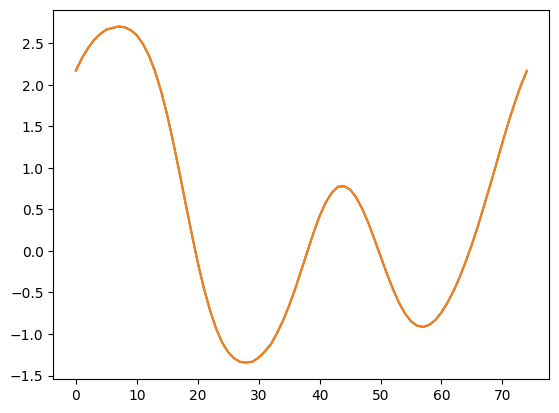

In [48]:
plt.plot(X_test_anode[idx][None,...][0,7,5:80,0])
plt.plot(I_func)

In [49]:
X_test_anode[idx][None,...][0,7,5:80,1].shape

(75,)

In [50]:
c_test_pred_anode_capefno = model_capefno.apply(params_anode_capefno,X_test_anode[idx][None,...], Dan.reshape(-1,1))
c_test_pred_anode_fno = model_fno.apply(params_anode_fno,X_test_anode[idx][None,...])
c_test_pred_anode_don = model_don.apply(params_anode_don,I_func,test_c0_anode_capefno[idx], trunk_points)


c_test_pred_cathode_capefno = model_capefno.apply(params_cathode_capefno,X_test_cathode[idx][None,...], Dca.reshape(-1,1))
c_test_pred_cathode_fno = model_fno.apply(params_cathode_fno,X_test_cathode[idx][None,...])
c_test_pred_cathode_don = model_don.apply(params_cathode_don,I_func,test_c0_cathode_capefno[idx], trunk_points)

In [51]:
c_test_pred_anode_don_reshaped = c_test_pred_anode_don.reshape(num_samples_I, num_samples_c0)
c_test_pred_anode_fno_reshaped = remove_padding(c_test_pred_anode_fno, padding_r, padding_t).squeeze()
c_test_pred_anode_capefno_reshaped = remove_padding(c_test_pred_anode_capefno, padding_r, padding_t).squeeze()

c_test_pred_cathode_don_reshaped = c_test_pred_cathode_don.reshape(num_samples_I, num_samples_c0)
c_test_pred_cathode_fno_reshaped = remove_padding(c_test_pred_cathode_fno, padding_r, padding_t).squeeze()
c_test_pred_cathode_capefno_reshaped = remove_padding(c_test_pred_cathode_capefno, padding_r, padding_t).squeeze()

In [52]:
c_test_pred_anode_don_reshaped = c_test_pred_anode_don.reshape(num_samples_c0,num_samples_I)
c_test_pred_cathode_don_reshaped = c_test_pred_cathode_don.reshape(num_samples_c0,num_samples_I)

In [53]:
cn_target_cathode - c_test_pred_cathode_don_reshaped

Array([[0.13361208, 0.13147457, 0.12343183, ..., 0.04299606, 0.03632006,
        0.02861442],
       [0.13380226, 0.13159594, 0.12353471, ..., 0.04319753, 0.03638661,
        0.02880029],
       [0.13400584, 0.1317288 , 0.12361166, ..., 0.04328696, 0.03655578,
        0.02893838],
       ...,
       [0.13703917, 0.12606959, 0.11611983, ..., 0.03879535, 0.03119378,
        0.0227804 ],
       [0.13719416, 0.12507077, 0.11501047, ..., 0.03831135, 0.03035308,
        0.02163692],
       [0.13749632, 0.12398271, 0.11387205, ..., 0.03754839, 0.02945936,
        0.02074626]], dtype=float32)

In [54]:
# c_test_true_anode_capefno_reshaped = remove_padding(Y_test_anode[idx][None,...], padding_r, padding_t).squeeze()
# cn_target_anode = c_test_true_anode_capefno_reshaped

In [55]:
print(np.mean((cn_target_cathode - c_test_pred_cathode_don_reshaped)**2)/np.mean(cn_target_cathode**2))
print(np.mean((cn_target_cathode - c_test_pred_cathode_fno_reshaped)**2)/np.mean(cn_target_cathode**2))
print(np.mean((cn_target_cathode - c_test_pred_cathode_capefno_reshaped)**2)/np.mean(cn_target_cathode**2)*100)

0.04094714
1.5939373e-05
0.024392936


In [56]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)

C = params_bat["Nominal cell capacity [A.h]"]
# Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
# Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]
t_max = 3600

t = np.linspace(0, 1, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [57]:
cn_target_anode_scaled = cn_target_anode * cs_max_a
cn_target_cathode_scaled = cn_target_cathode * cs_max_c

In [58]:
c_test_pred_anode_don_reshaped_scaled = c_test_pred_anode_don_reshaped * cs_max_a
c_test_pred_anode_fno_reshaped_scaled = c_test_pred_anode_fno_reshaped * cs_max_a
c_test_pred_anode_capefno_reshaped_scaled = c_test_pred_anode_capefno_reshaped * cs_max_a

c_test_pred_cathode_don_reshaped_scaled = c_test_pred_cathode_don_reshaped * cs_max_c
c_test_pred_cathode_fno_reshaped_scaled = c_test_pred_cathode_fno_reshaped * cs_max_c
c_test_pred_cathode_capefno_reshaped_scaled = c_test_pred_cathode_capefno_reshaped * cs_max_c

In [59]:
c_pred_an_surf_don = c_test_pred_anode_don_reshaped[-1,:]
c_pred_ca_surf_don = c_test_pred_cathode_don_reshaped[-1,:]

c_pred_an_surf_fno = c_test_pred_anode_fno_reshaped[-1,:]
c_pred_ca_surf_fno = c_test_pred_cathode_fno_reshaped[-1,:]

c_pred_an_surf_capefno = c_test_pred_anode_capefno_reshaped[-1,:]
c_pred_ca_surf_capefno = c_test_pred_cathode_capefno_reshaped[-1,:]

In [60]:
cn_target_an_surf = cn_target_anode[-1,:]
cn_target_ca_surf = cn_target_cathode[-1,:]

In [61]:
V_pred_don, V_true = functions.post_proc(params_bat, I_func, c_pred_an_surf_don, cn_target_an_surf, c_pred_ca_surf_don, cn_target_ca_surf, Ran, Rca, epsan, epsca, Lan, Lca, A)
V_pred_fno, _ = functions.post_proc(params_bat, I_func, c_pred_an_surf_fno, cn_target_an_surf, c_pred_ca_surf_fno, cn_target_ca_surf, Ran, Rca, epsan, epsca, Lan, Lca, A)
V_pred_capefno, _ = functions.post_proc(params_bat, I_func, c_pred_an_surf_capefno, cn_target_an_surf, c_pred_ca_surf_capefno, cn_target_ca_surf, Ran, Rca, epsan, epsca, Lan, Lca, A)

In [62]:
c_test_pred_anode_don_reshaped_scaled

Array([[16837.201, 16843.537, 16850.367, ..., 17273.623, 17280.016,
        17285.37 ],
       [16805.998, 16812.25 , 16816.555, ..., 17241.188, 17247.553,
        17254.244],
       [16772.908, 16778.395, 16785.129, ..., 17206.818, 17215.678,
        17220.104],
       ...,
       [16287.322, 16294.426, 16299.347, ..., 16721.236, 16729.95 ,
        16736.215],
       [16253.829, 16260.1  , 16266.973, ..., 16689.375, 16696.023,
        16701.348],
       [16221.773, 16229.51 , 16232.971, ..., 16658.688, 16664.26 ,
        16668.008]], dtype=float32)

In [63]:
V_true - V_pybamm

Array([-1.58030987e-02, -1.62165165e-02, -1.65164471e-02, -1.68566704e-02,
       -1.73604488e-02, -1.85062885e-02, -2.10895538e-02, -2.51610279e-02,
       -2.73127556e-02, -2.52702236e-02, -2.20029354e-02, -1.97005272e-02,
       -1.83222294e-02, -1.73184872e-02, -1.63009167e-02, -1.49915218e-02,
       -1.31456852e-02, -1.05531216e-02, -7.07268715e-03, -2.95877457e-03,
        1.31940842e-03,  5.24973869e-03,  8.89992714e-03,  1.16906166e-02,
        1.27725601e-02,  1.28099918e-02,  1.26841068e-02,  1.25796795e-02,
        1.24444962e-02,  1.23045444e-02,  1.19774342e-02,  1.15048885e-02,
        1.09169483e-02,  9.95564461e-03,  8.72325897e-03,  7.10582733e-03,
        5.07092476e-03,  2.64096260e-03,  6.50882721e-05, -2.47573853e-03,
       -4.70948219e-03, -6.40869141e-03, -7.59816170e-03, -8.34941864e-03,
       -8.56757164e-03, -8.37206841e-03, -7.58767128e-03, -6.20388985e-03,
       -4.27579880e-03, -1.85728073e-03,  6.75439835e-04,  3.10564041e-03,
        5.15413284e-03,  

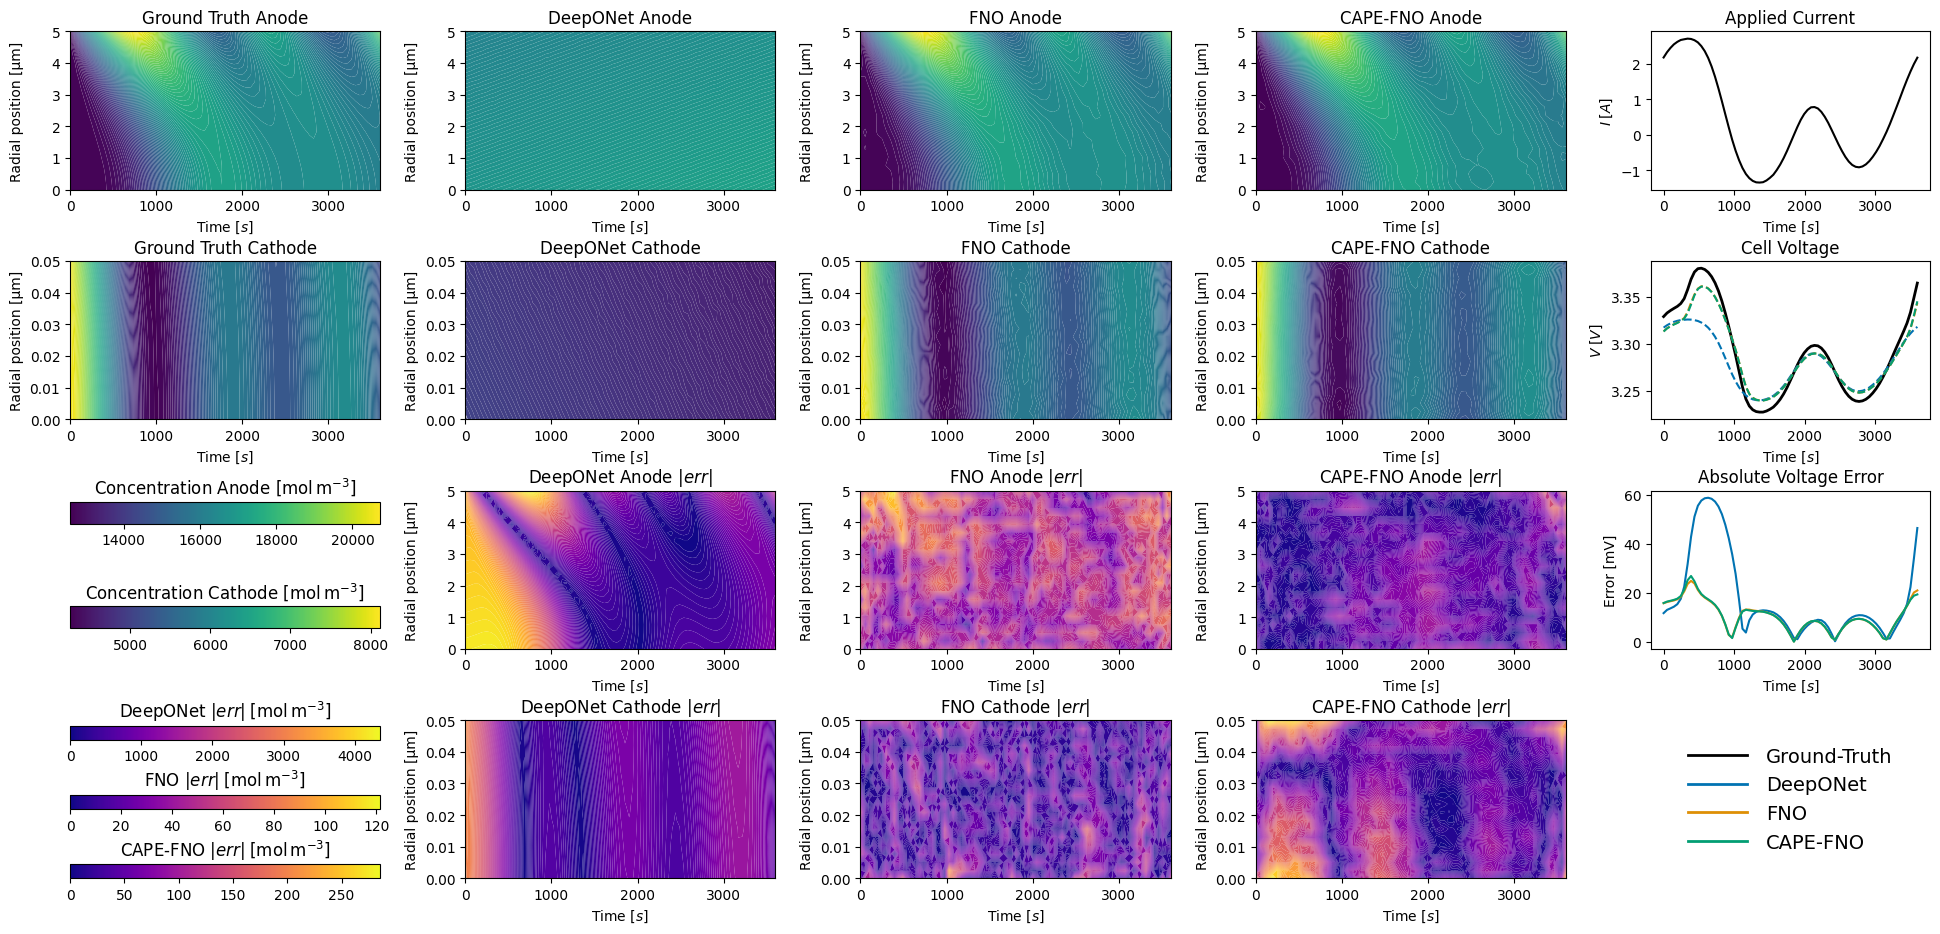

In [ ]:
pred_sets = [
    {   # first model
        'anode'  : c_test_pred_anode_don_reshaped_scaled,     # shape (R,T)
        'cathode': c_test_pred_cathode_don_reshaped_scaled,   # shape (R,T)
        'V'      : V_pred_don            # shape (T,)
    },
    {   # second model
        'anode'  : c_test_pred_anode_fno_reshaped_scaled,
        'cathode': c_test_pred_cathode_fno_reshaped_scaled,
        'V'      : V_pred_fno
    },
    {   # third model
        'anode'  : c_test_pred_anode_capefno_reshaped_scaled,
        'cathode': c_test_pred_cathode_capefno_reshaped_scaled,
        'V'      : V_pred_capefno
    }
]

fig, axes = create_plot_paper11(
    pred_sets,
    cn_target_anode_scaled, cn_target_cathode_scaled,
    I_func, V_true,
    t_max, Ran, Rca,
    pred_labels=['DeepONet', 'FNO', 'CAPE-FNO']
)

fig.savefig(f"../plots/paper/bfplot/idx{idx}.svg", dpi=600, bbox_inches='tight')
fig.show()


In [65]:
for idx, I_func in enumerate(test_I_capefno):
    spm = pybamm.lithium_ion.SPM()
    spm.events = []
    params_local = pybamm.ParameterValues("Prada2013")
    params_local["Current function [A]"] = pybamm.Interpolant(t_eval, -1. * I_func, pybamm.t)
    # params_local["Negative particle diffusivity [m2.s-1]"] = 10 ** Dan[0]
    # params_local["Positive particle diffusivity [m2.s-1]"] = 10 ** Dca[0]
    sim = pybamm.Simulation(spm, parameter_values=params_local)
    sol = sim.solve(initial_soc=float(test_soc_capefno[idx]), t_eval=t_eval)

    # c0_anode = sol["Negative particle concentration"].entries[:, 0, 0]
    cn_target_anode = sol["Negative particle concentration"].entries[:, 0, :]
    # c0_cathode = sol["Positive particle concentration"].entries[:, 0, 0]
    cn_target_cathode = sol["Positive particle concentration"].entries[:, 0, :]

    V_pybamm = sol["Terminal voltage [V]"].entries

    c_test_pred_anode_capefno = model_capefno.apply(params_anode_capefno,X_test_anode[idx][None,...], Dan.reshape(-1,1))
    c_test_pred_anode_fno = model_fno.apply(params_anode_fno,X_test_anode[idx][None,...])
    c_test_pred_anode_don = model_don.apply(params_anode_don,I_func,test_c0_anode_capefno[idx], trunk_points)


    c_test_pred_cathode_capefno = model_capefno.apply(params_cathode_capefno,X_test_cathode[idx][None,...], Dca.reshape(-1,1))
    c_test_pred_cathode_fno = model_fno.apply(params_cathode_fno,X_test_cathode[idx][None,...])
    c_test_pred_cathode_don = model_don.apply(params_cathode_don,I_func,test_c0_cathode_capefno[idx], trunk_points)

    c_test_pred_anode_don_reshaped = c_test_pred_anode_don.reshape(num_samples_I, num_samples_c0)
    c_test_pred_anode_fno_reshaped = remove_padding(c_test_pred_anode_fno, padding_r, padding_t).squeeze()
    c_test_pred_anode_capefno_reshaped = remove_padding(c_test_pred_anode_capefno, padding_r, padding_t).squeeze()

    c_test_pred_cathode_don_reshaped = c_test_pred_cathode_don.reshape(num_samples_I, num_samples_c0)
    c_test_pred_cathode_fno_reshaped = remove_padding(c_test_pred_cathode_fno, padding_r, padding_t).squeeze()
    c_test_pred_cathode_capefno_reshaped = remove_padding(c_test_pred_cathode_capefno, padding_r, padding_t).squeeze()

    c_test_pred_anode_don_reshaped = c_test_pred_anode_don.reshape(num_samples_c0,num_samples_I)
    c_test_pred_cathode_don_reshaped = c_test_pred_cathode_don.reshape(num_samples_c0,num_samples_I)
    
    parameter_name = "Prada2013"
    params_bat = pybamm.ParameterValues(parameter_name)

    C = params_bat["Nominal cell capacity [A.h]"]
    # Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
    # Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
    Ran = params_bat["Negative particle radius [m]"]
    Rca = params_bat["Positive particle radius [m]"]
    epsan = params_bat["Negative electrode active material volume fraction"]
    epsca = params_bat["Positive electrode active material volume fraction"]
    cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
    cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
    Lan = params_bat["Negative electrode thickness [m]"]
    Lca = params_bat["Positive electrode thickness [m]"]
    A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]
    t_max = 3600

    t = np.linspace(0, 1, num_samples_I)
    r = np.linspace(0, 1, num_samples_c0)

    cn_target_anode_scaled = cn_target_anode * cs_max_a
    cn_target_cathode_scaled = cn_target_cathode * cs_max_c

    c_test_pred_anode_don_reshaped_scaled = c_test_pred_anode_don_reshaped * cs_max_a
    c_test_pred_anode_fno_reshaped_scaled = c_test_pred_anode_fno_reshaped * cs_max_a
    c_test_pred_anode_capefno_reshaped_scaled = c_test_pred_anode_capefno_reshaped * cs_max_a

    c_test_pred_cathode_don_reshaped_scaled = c_test_pred_cathode_don_reshaped * cs_max_c
    c_test_pred_cathode_fno_reshaped_scaled = c_test_pred_cathode_fno_reshaped * cs_max_c
    c_test_pred_cathode_capefno_reshaped_scaled = c_test_pred_cathode_capefno_reshaped * cs_max_c

    c_pred_an_surf_don = c_test_pred_anode_don_reshaped[-1,:]
    c_pred_ca_surf_don = c_test_pred_cathode_don_reshaped[-1,:]

    c_pred_an_surf_fno = c_test_pred_anode_fno_reshaped[-1,:]
    c_pred_ca_surf_fno = c_test_pred_cathode_fno_reshaped[-1,:]

    c_pred_an_surf_capefno = c_test_pred_anode_capefno_reshaped[-1,:]
    c_pred_ca_surf_capefno = c_test_pred_cathode_capefno_reshaped[-1,:]
    
    cn_target_an_surf = cn_target_anode[-1,:]
    cn_target_ca_surf = cn_target_cathode[-1,:]

    V_pred_don, V_true = functions.post_proc(params_bat, I_func, c_pred_an_surf_don, cn_target_an_surf, c_pred_ca_surf_don, cn_target_ca_surf, Ran, Rca, epsan, epsca, Lan, Lca, A)
    V_pred_fno, _ = functions.post_proc(params_bat, I_func, c_pred_an_surf_fno, cn_target_an_surf, c_pred_ca_surf_fno, cn_target_ca_surf, Ran, Rca, epsan, epsca, Lan, Lca, A)
    V_pred_capefno, _ = functions.post_proc(params_bat, I_func, c_pred_an_surf_capefno, cn_target_an_surf, c_pred_ca_surf_capefno, cn_target_ca_surf, Ran, Rca, epsan, epsca, Lan, Lca, A)

    pred_sets = [
        {   # first model
            'anode'  : c_test_pred_anode_don_reshaped_scaled,     # shape (R,T)
            'cathode': c_test_pred_cathode_don_reshaped_scaled,   # shape (R,T)
            'V'      : V_pred_don            # shape (T,)
        },
        {   # second model
            'anode'  : c_test_pred_anode_fno_reshaped_scaled,
            'cathode': c_test_pred_cathode_fno_reshaped_scaled,
            'V'      : V_pred_fno
        },
        {   # third model
            'anode'  : c_test_pred_anode_capefno_reshaped_scaled,
            'cathode': c_test_pred_cathode_capefno_reshaped_scaled,
            'V'      : V_pred_capefno
    }
    ]

    if np.allclose(V_true, V_pybamm):
        print("V_true matches V_pybamm for index", idx)
    else:
        continue

    fig, axes = create_plot_paper11(
        pred_sets,
        cn_target_anode_scaled, cn_target_cathode_scaled,
        I_func, V_true,
        t_max, Ran, Rca,
        pred_labels=['DeepONet', 'FNO', 'CAPE-FNO']
    )

    fig.savefig(f"../plots/paper/bfplot/idx{idx}.svg", dpi=600, bbox_inches='tight')
    print(f"Plot saved for index {idx}")
    # fig.show()

    